## Invasive Area Plots

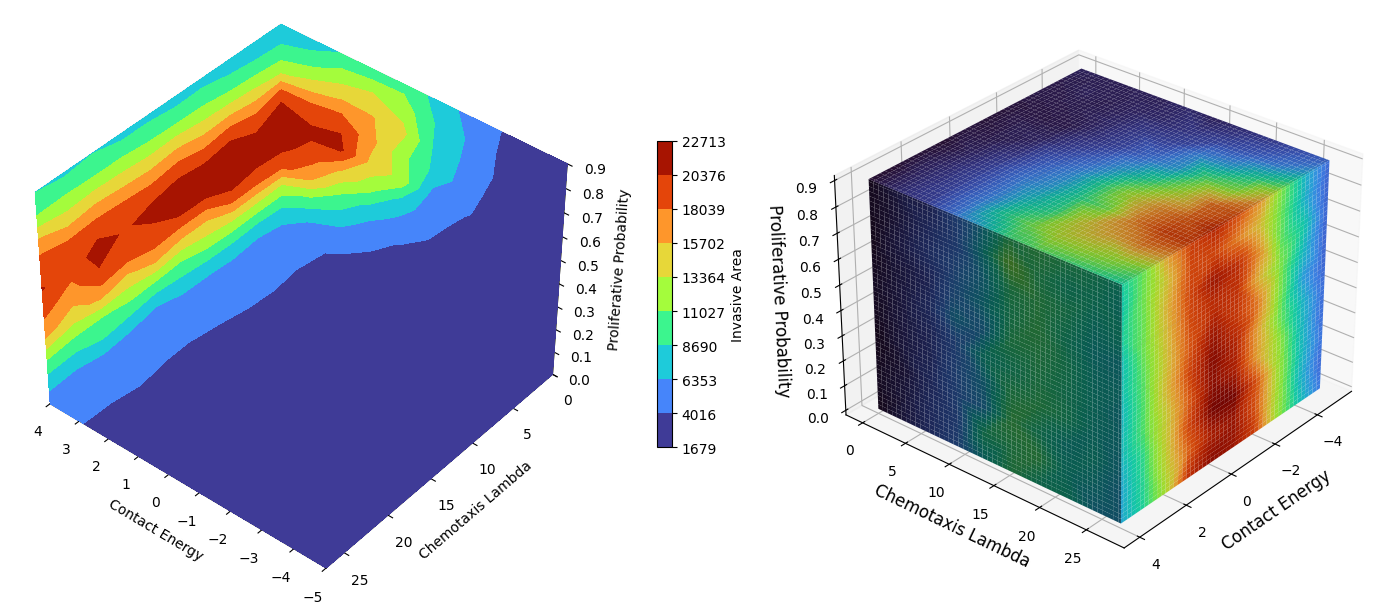

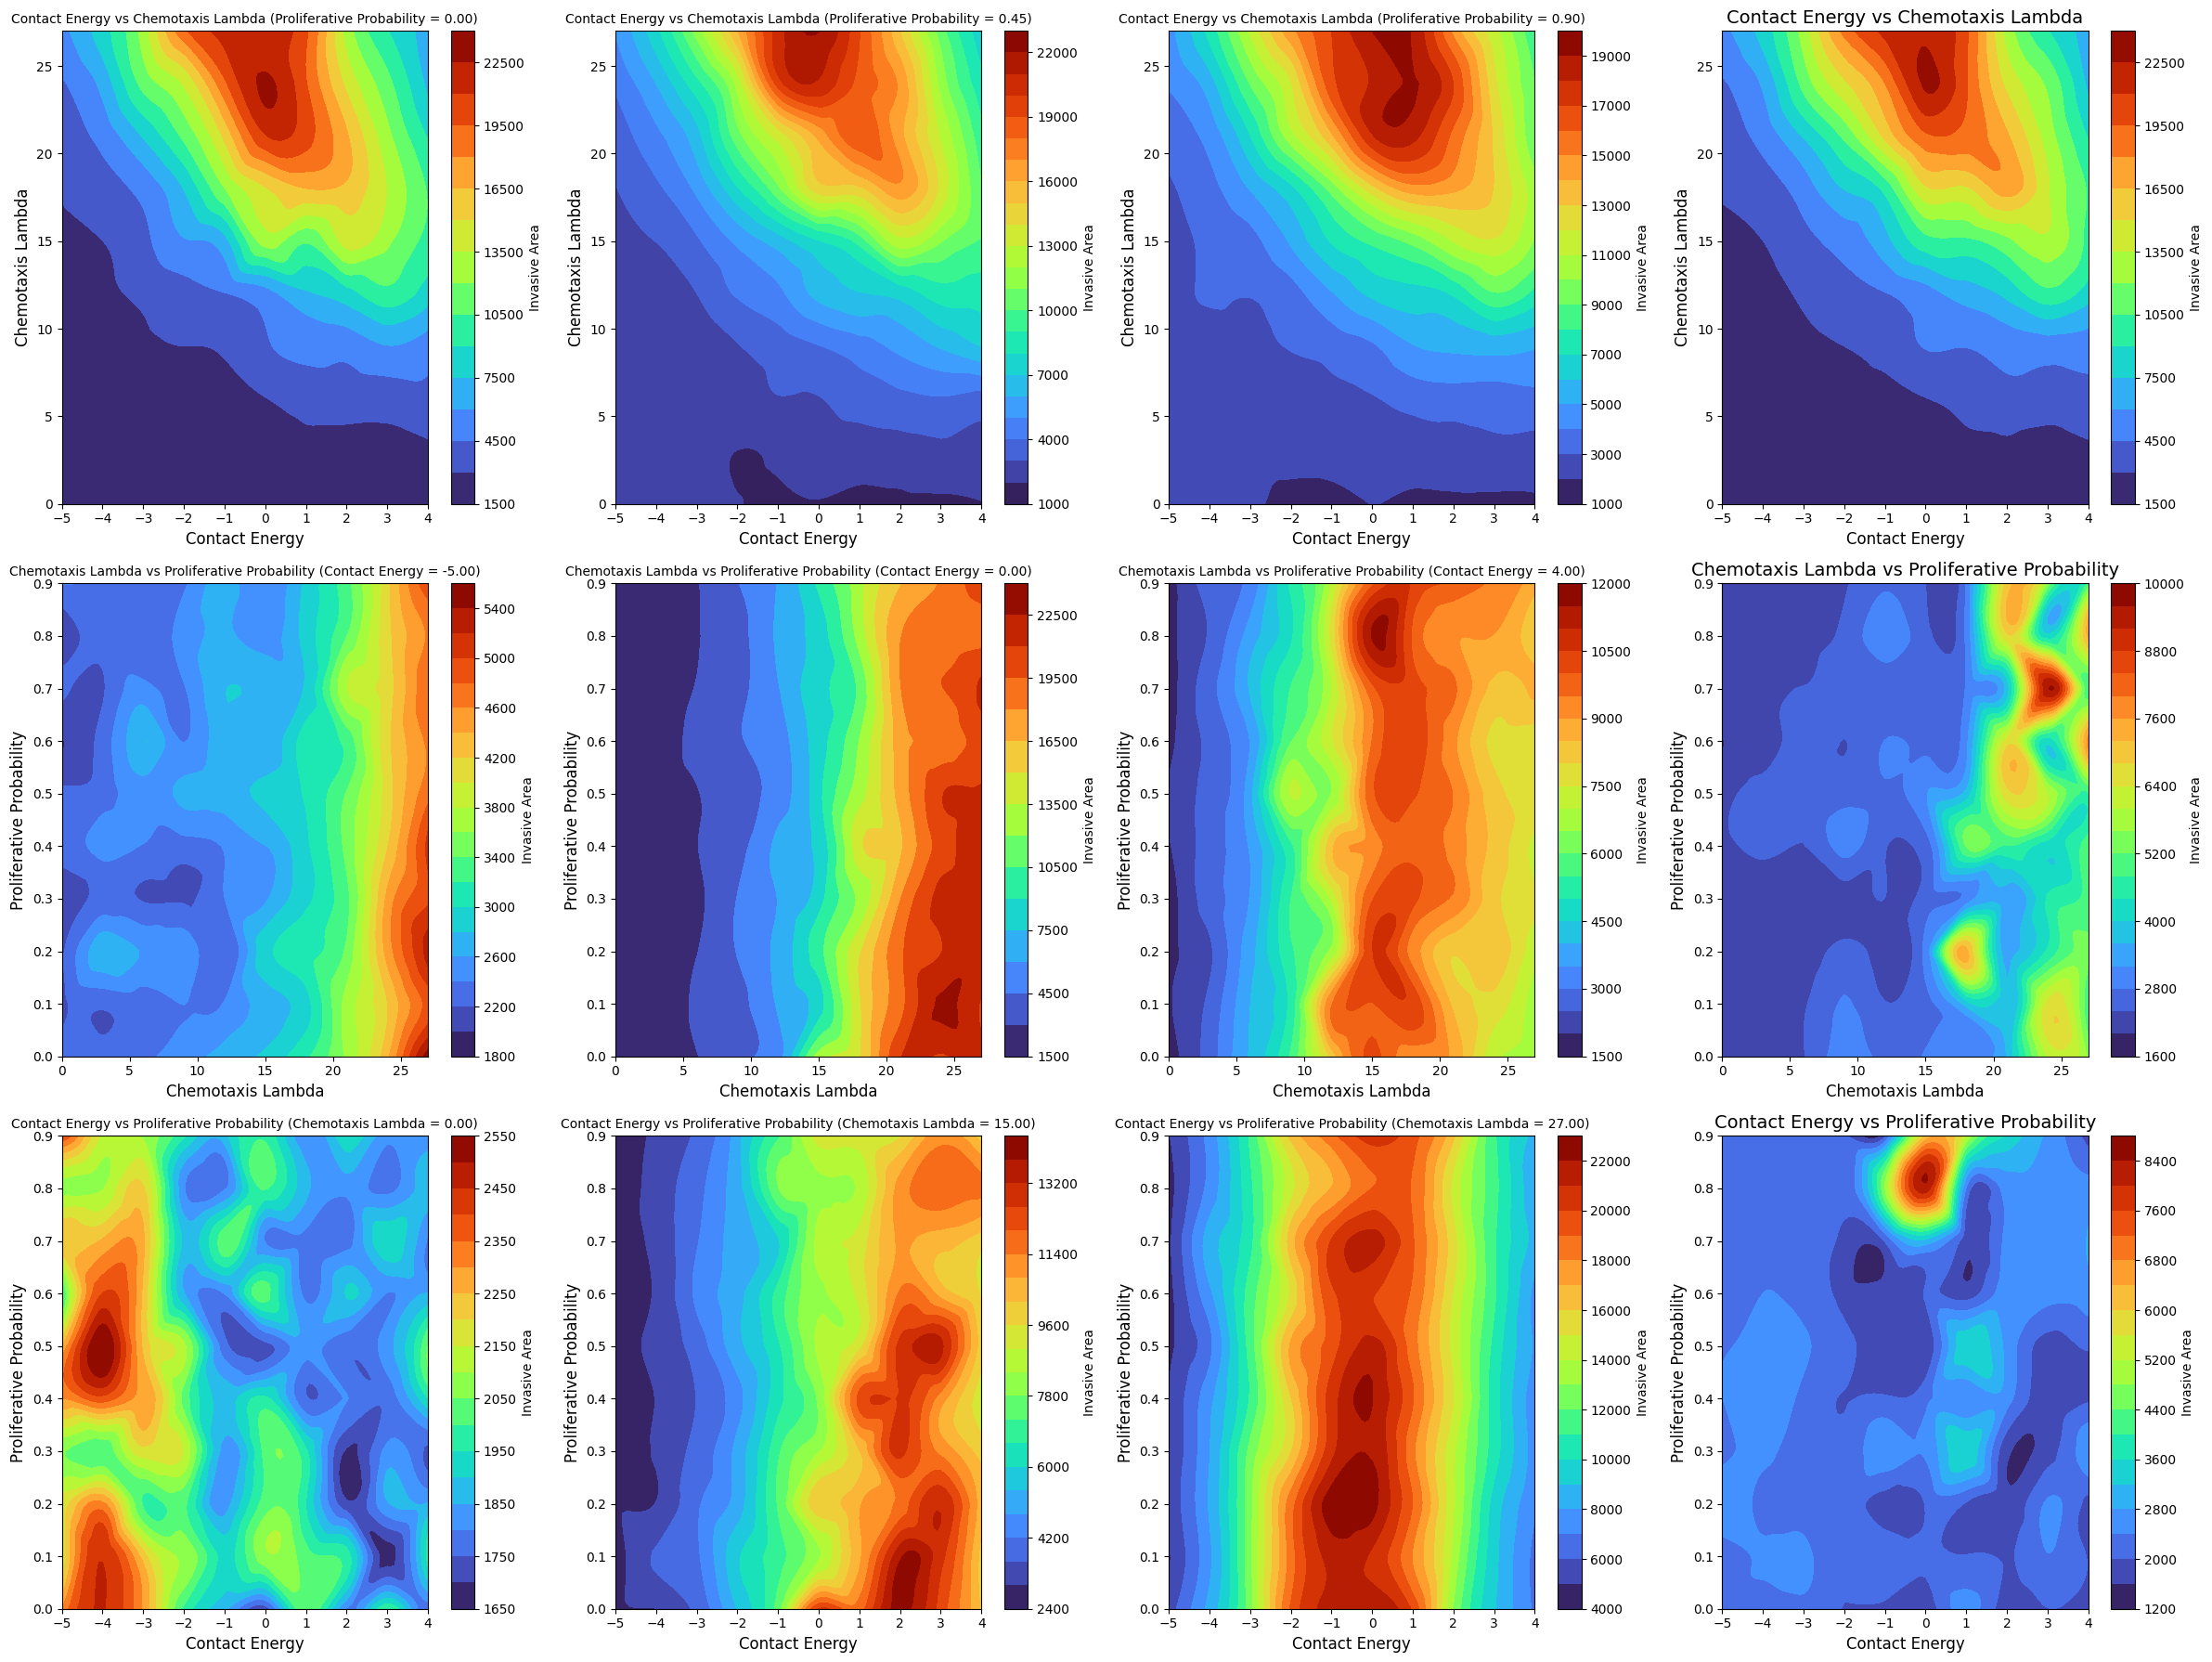

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Load the dataset
file_path = "/Users/sheriffakeeb/Desktop/Sample_Simulation/Outputs/Invasive_Area_Mean.csv" 
df = pd.read_csv(file_path)

# Extract data from the dataset
x = df["Contact Energy"].values  
y = df["Chemotaxis Lambda"].values  
z = df["Proliferative Probability"].values  
c = df["Invasive Area"].values  

# Normalize the invasive area for color mapping
c_norm = (c - c.min()) / (c.max() - c.min())

# Define the cube boundaries
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

# Create meshgrid for cube faces
X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Interpolate color values across cube faces
grid_points = np.array([x, y, z]).T
grid_values = c_norm

C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())  # Max Y
C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())  # Max X
C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())  # Max Z

# Normalize colors for each face separately
C_left_norm = (C_left - c.min()) / (c.max() - c.min())
C_right_norm = (C_right - c.min()) / (c.max() - c.min())
C_top_norm = (C_top - c.min()) / (c.max() - c.min())

# Define grid size for interpolation
Nx, Ny, Nz = 10, 10, 10  # Adjusting for computational efficiency
P, Q, R = np.meshgrid(np.linspace(x.min(), x.max(), Nx),
                       np.linspace(y.min(), y.max(), Ny),
                       np.linspace(z.min(), z.max(), Nz))

# Reshape the invasive area data
c_grid = c.reshape((Nx, Ny, Nz), order='F')

# Define contour levels and limits
kw = {
    'vmin': c_grid.min(),
    'vmax': c_grid.max(),
    'levels': np.linspace(c_grid.min(), c_grid.max(), 10),
    'cmap': 'turbo',
}

# Create figure with subplots
fig = plt.figure(figsize=(16, 6))

# First subplot - Contour plot (formerly ax2, now ax1)
ax1 = fig.add_subplot(121, projection='3d')

# Plot contour surfaces
_ = ax1.contourf(
    P[:, :, 0], Q[:, :, 0], c_grid[:, :, 0],
    zdir='z', offset=z.min(), **kw
)
_ = ax1.contourf(
    P[0, :, :], c_grid[0, :, :], R[0, :, :],
    zdir='y', offset=y.min(), **kw
)
C = ax1.contourf(
    c_grid[:, -1, :], Q[:, -1, :], R[:, -1, :],
    zdir='x', offset=x.max(), **kw
)

# Set plot limits and labels
ax1.set(
    xlim=[P.min(), P.max()],
    ylim=[Q.min(), Q.max()],
    zlim=[R.min(), R.max()],
    xlabel='Contact Energy',
    ylabel='Chemotaxis Lambda',
    zlabel='Proliferative Probability',
)

# Set view angle
ax1.view_init(40, 130)


# Second subplot - Cube with interpolated faces (formerly ax1, now ax2)
ax2 = fig.add_subplot(122, projection='3d')

# Define colormap normalization
norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())
colormap = cm.turbo

# Plot cube faces with color mapping
ax2.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(C_left_norm), edgecolor='none', alpha=1.0)  # Max Y face
ax2.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(C_right_norm), edgecolor='none', alpha=1.0)  # Max X face
ax2.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(C_top_norm), edgecolor='none', alpha=1.0)  # Max Z face

# Set axis labels
ax2.set_xlabel("Contact Energy", fontsize=12)
ax2.set_ylabel("Chemotaxis Lambda", fontsize=12)
ax2.set_zlabel("Proliferative Probability", fontsize=12)

# Adjust viewing angle
ax2.view_init(elev=30, azim=40)

# Add colorbar to ax1 (contour plot)
fig.colorbar(C, ax=ax1, fraction=0.02, pad=0.1, label='Invasive Area')

# Show combined plots
plt.tight_layout()
plt.show()



# --------------------------------------
# Generate 2D Plots
# --------------------------------------


# Define midpoints
x_half_new = 0
y_half_new = 15
z_half = (z.max() + z.min()) / 2

# Function to plot 2D contours for fixed parameter values
def plot_fixed_param_contours(ax, fixed_param, fixed_values, param1, param2, param1_label, param2_label):
    for i, val in enumerate(fixed_values):
        mask = np.isclose(df[fixed_param], val, atol=0.1)
        subset = df[mask]
        
        if subset.empty:
            continue

        X, Y = np.meshgrid(
            np.linspace(subset[param1].min(), subset[param1].max(), 100),
            np.linspace(subset[param2].min(), subset[param2].max(), 100)
        )

        Z = griddata((subset[param1], subset[param2]), subset["Invasive Area"], (X, Y), method='cubic')
        
        if np.isnan(Z).all():
            Z = griddata((subset[param1], subset[param2]), subset["Invasive Area"], (X, Y), method='nearest')

        contour = ax[i].contourf(X, Y, Z, levels=20, cmap='turbo')
        ax[i].set_xlabel(param1_label, fontsize=12)
        ax[i].set_ylabel(param2_label, fontsize=12)
        ax[i].set_title(f"{param1_label} vs {param2_label} ({fixed_param} = {val:.2f})", fontsize=10)
        fig.colorbar(contour, ax=ax[i], label="Invasive Area")

# Function to plot a single 2D contour plot
def plot_2D_contour(ax, param1, param2, param1_label, param2_label):
    X, Y = np.meshgrid(np.linspace(df[param1].min(), df[param1].max(), 100),
                        np.linspace(df[param2].min(), df[param2].max(), 100))
    
    Z = griddata((df[param1], df[param2]), df["Invasive Area"], (X, Y), method='cubic')

    contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo')
    ax.set_xlabel(param1_label, fontsize=12)
    ax.set_ylabel(param2_label, fontsize=12)
    ax.set_title(f"{param1_label} vs {param2_label}", fontsize=14)
    fig.colorbar(contour, ax=ax, label="Invasive Area")

# Create figure with subplots arranged in the desired order
fig, axes = plt.subplots(3, 4, figsize=(24, 18))

# Plot Contact Energy vs Chemotaxis Lambda for different Proliferative Probability values
plot_fixed_param_contours(axes[0, :3], "Proliferative Probability", [z.min(), z_half, z.max()], 
                          "Contact Energy", "Chemotaxis Lambda", "Contact Energy", "Chemotaxis Lambda")

# Plot 2D contour plot for Contact Energy vs Chemotaxis Lambda
plot_2D_contour(axes[0, 3], "Contact Energy", "Chemotaxis Lambda", "Contact Energy", "Chemotaxis Lambda")

# Plot Chemotaxis Lambda vs Proliferative Probability for different Contact Energy values
plot_fixed_param_contours(axes[1, :3], "Contact Energy", [x.min(), x_half_new, x.max()], 
                          "Chemotaxis Lambda", "Proliferative Probability", "Chemotaxis Lambda", "Proliferative Probability")

# Plot 2D contour plot for Chemotaxis Lambda vs Proliferative Probability
plot_2D_contour(axes[1, 3], "Chemotaxis Lambda", "Proliferative Probability", "Chemotaxis Lambda", "Proliferative Probability")

# Plot Contact Energy vs Proliferative Probability for different Chemotaxis Lambda values
plot_fixed_param_contours(axes[2, :3], "Chemotaxis Lambda", [y.min(), y_half_new, y.max()], 
                          "Contact Energy", "Proliferative Probability", "Contact Energy", "Proliferative Probability")

# Plot 2D contour plot for Contact Energy vs Proliferative Probability
plot_2D_contour(axes[2, 3], "Contact Energy", "Proliferative Probability", "Contact Energy", "Proliferative Probability")

# Adjust layout and show plots
plt.tight_layout()
plt.show()



## Infiltrative Area Plot

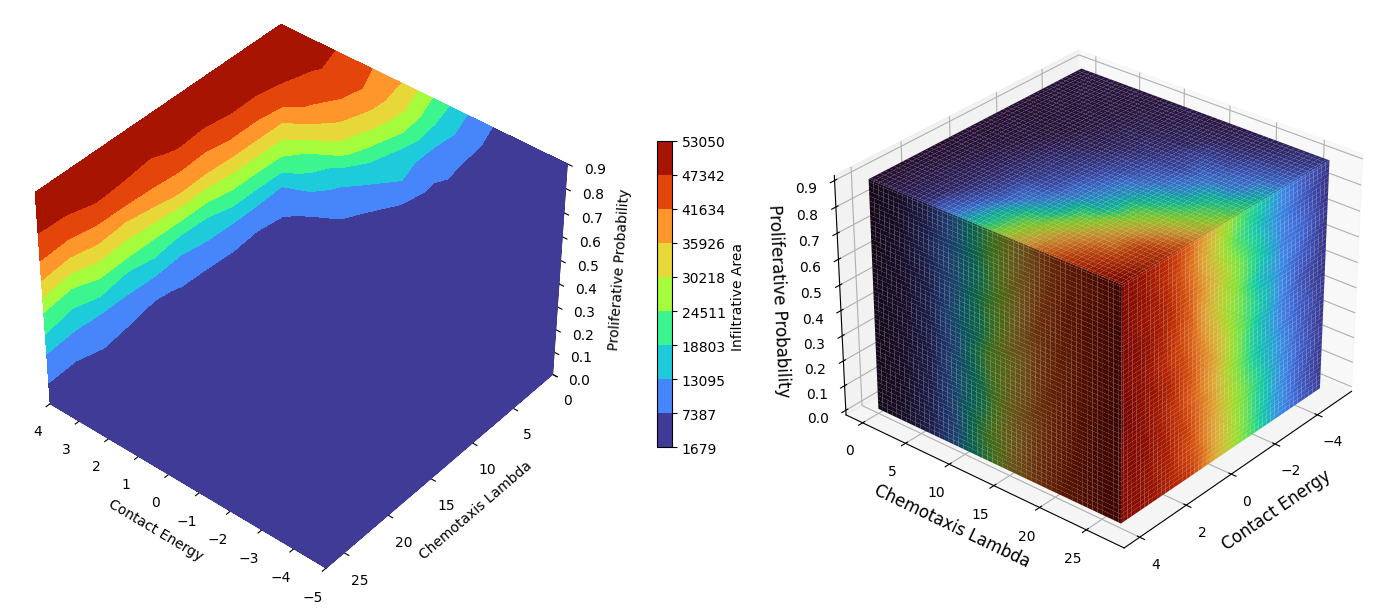

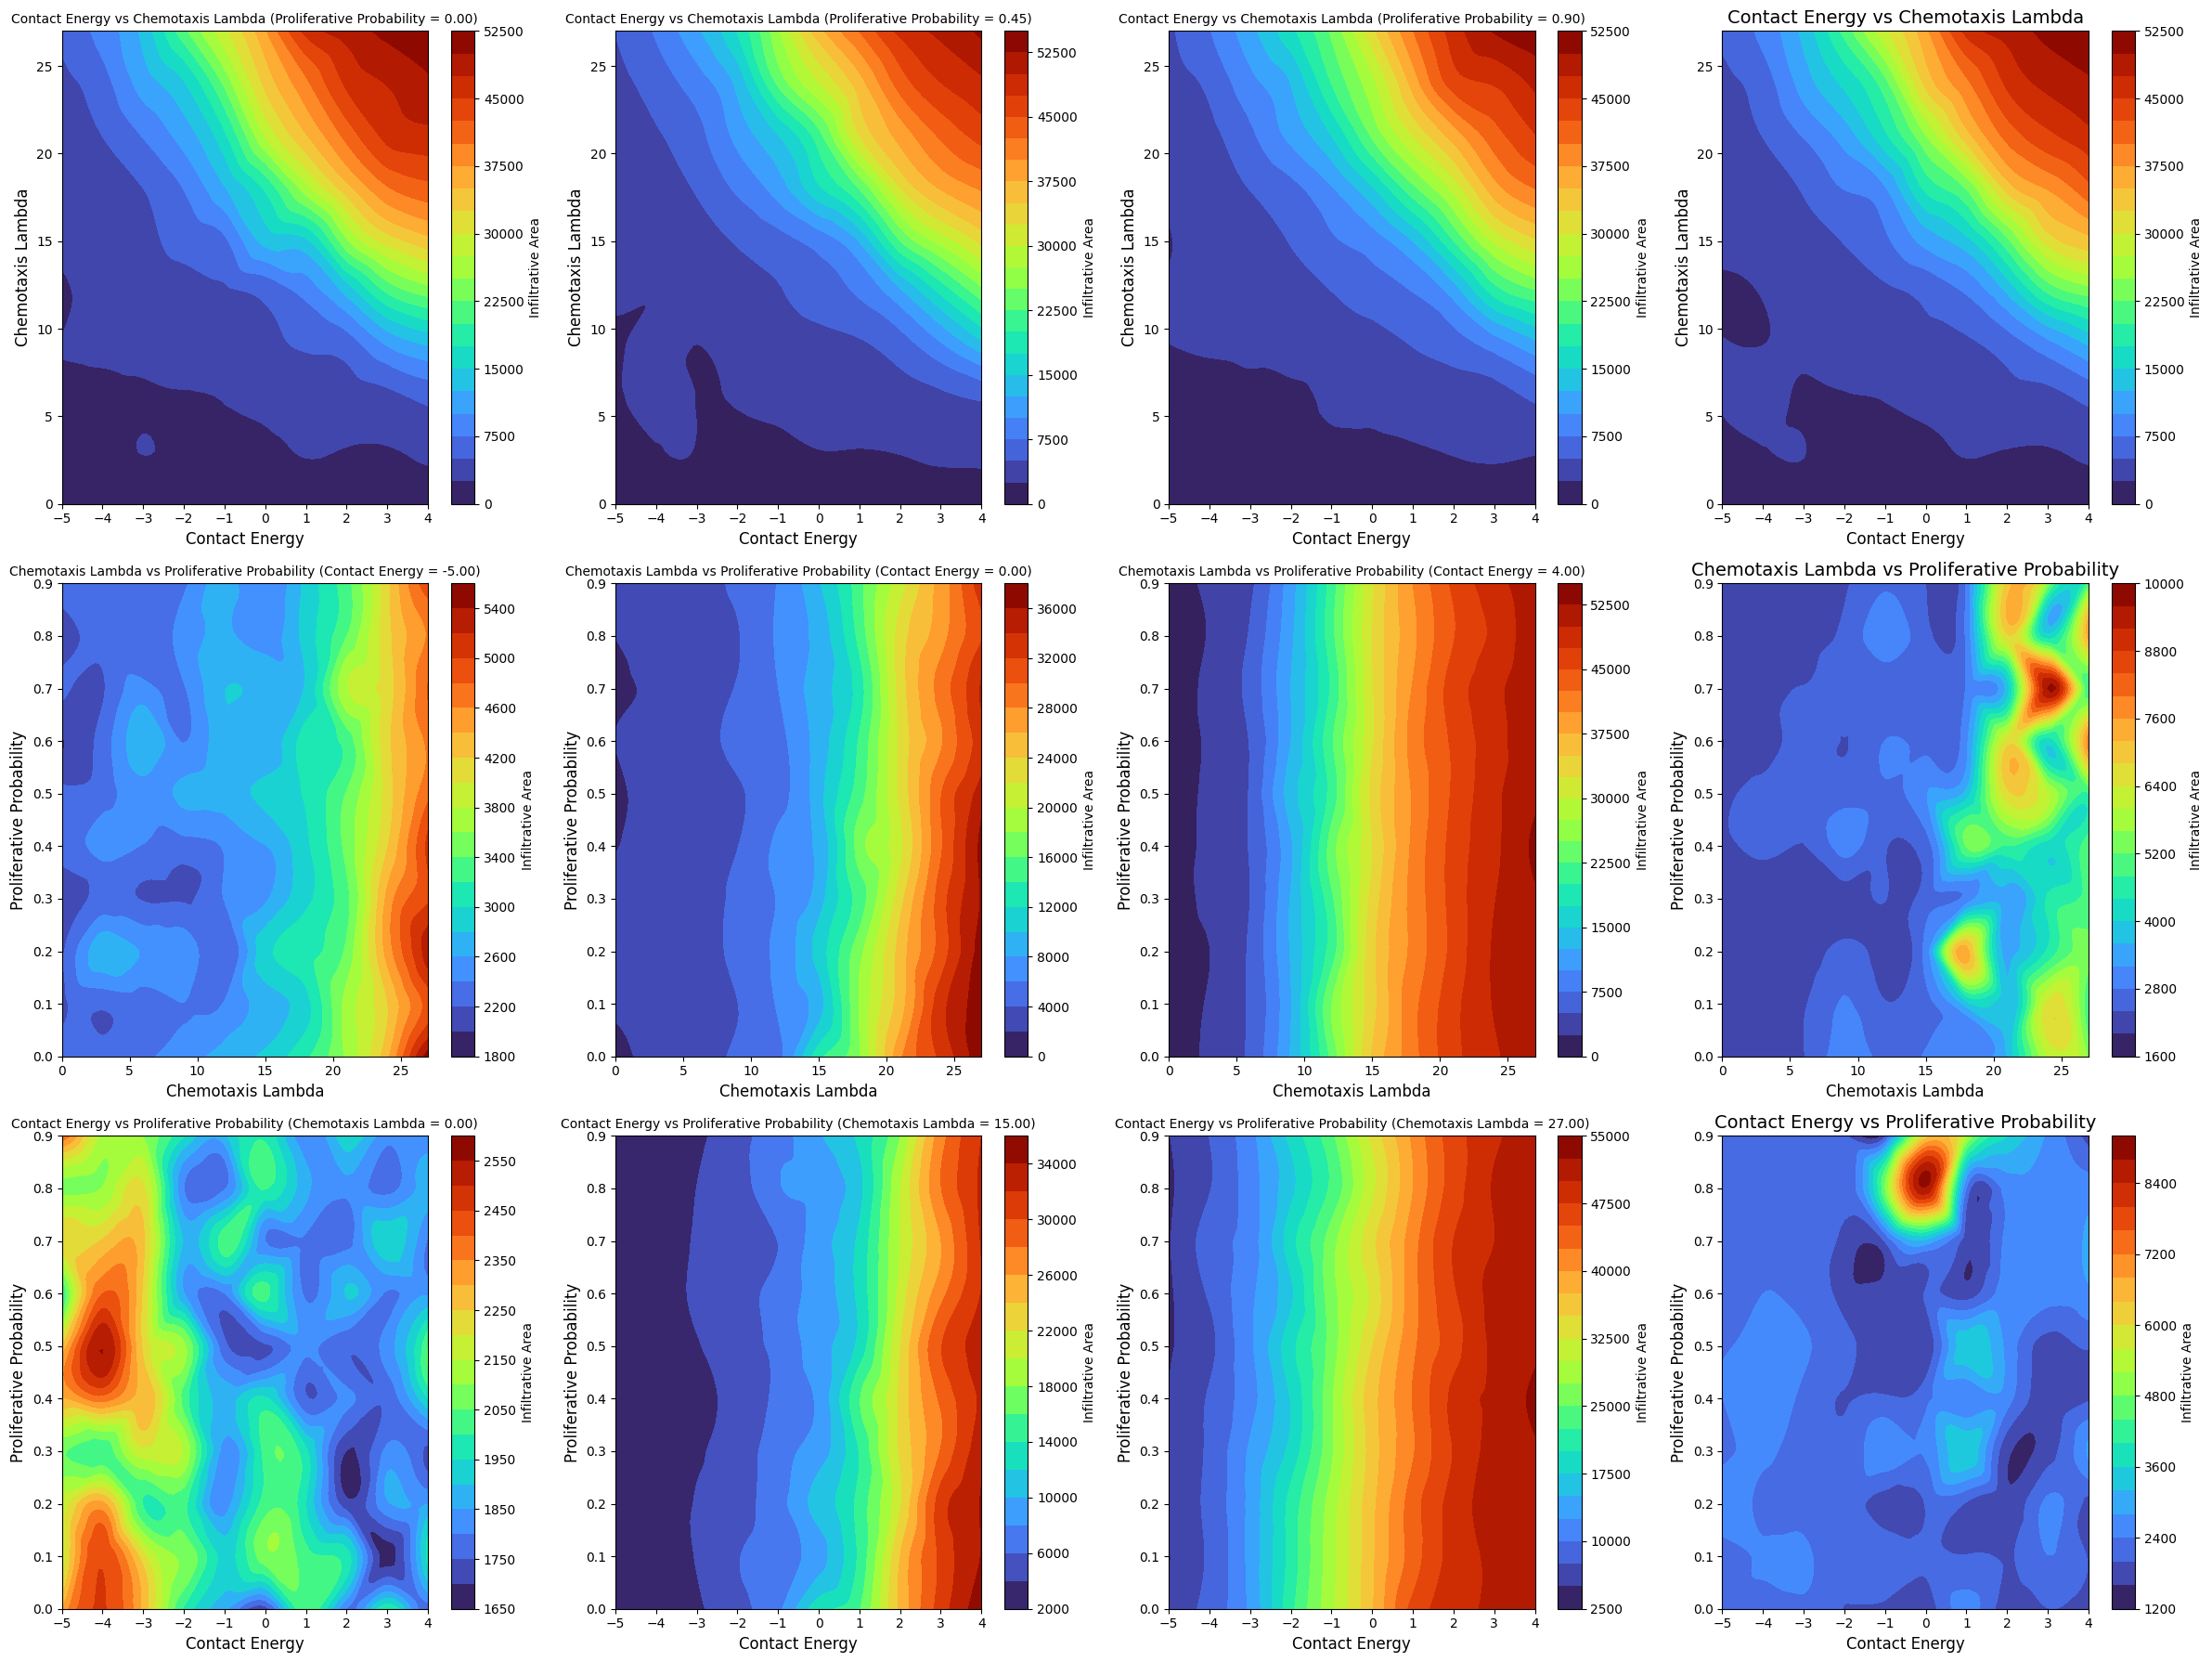

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Load the dataset
file_path = "/Users/sheriffakeeb/Desktop/Sample_Simulation/Outputs/Infiltrative_Area_Mean.csv" 
df = pd.read_csv(file_path)

# Extract data from the dataset
x = df["Contact Energy"].values  
y = df["Chemotaxis Lambda"].values  
z = df["Proliferative Probability"].values  
c = df["Infiltrative Area"].values  

# Normalize the invasive area for color mapping
c_norm = (c - c.min()) / (c.max() - c.min())

# Define the cube boundaries
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

# Create meshgrid for cube faces
X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Interpolate color values across cube faces
grid_points = np.array([x, y, z]).T
grid_values = c_norm

C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())  # Max Y
C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())  # Max X
C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())  # Max Z

# Normalize colors for each face separately
C_left_norm = (C_left - c.min()) / (c.max() - c.min())
C_right_norm = (C_right - c.min()) / (c.max() - c.min())
C_top_norm = (C_top - c.min()) / (c.max() - c.min())

# Define grid size for interpolation
Nx, Ny, Nz = 10, 10, 10  # Adjusting for computational efficiency
P, Q, R = np.meshgrid(np.linspace(x.min(), x.max(), Nx),
                       np.linspace(y.min(), y.max(), Ny),
                       np.linspace(z.min(), z.max(), Nz))

# Reshape the invasive area data
c_grid = c.reshape((Nx, Ny, Nz), order='F')

# Define contour levels and limits
kw = {
    'vmin': c_grid.min(),
    'vmax': c_grid.max(),
    'levels': np.linspace(c_grid.min(), c_grid.max(), 10),
    'cmap': 'turbo'
}

# Create figure with subplots
fig = plt.figure(figsize=(16, 6))

# First subplot - Contour plot (formerly ax2, now ax1)
ax1 = fig.add_subplot(121, projection='3d')

# Plot contour surfaces
_ = ax1.contourf(
    P[:, :, 0], Q[:, :, 0], c_grid[:, :, 0],
    zdir='z', offset=z.min(), **kw
)
_ = ax1.contourf(
    P[0, :, :], c_grid[0, :, :], R[0, :, :],
    zdir='y', offset=y.min(), **kw
)
C = ax1.contourf(
    c_grid[:, -1, :], Q[:, -1, :], R[:, -1, :],
    zdir='x', offset=x.max(), **kw
)

# Set plot limits and labels
ax1.set(
    xlim=[P.min(), P.max()],
    ylim=[Q.min(), Q.max()],
    zlim=[R.min(), R.max()],
    xlabel='Contact Energy',
    ylabel='Chemotaxis Lambda',
    zlabel='Proliferative Probability',
)
colormap = cm.plasma
# Set view angle
ax1.view_init(40, 130)

# Second subplot - Cube with interpolated faces (formerly ax1, now ax2)
ax2 = fig.add_subplot(122, projection='3d')

# Define colormap normalization
norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())
colormap = cm.turbo

# Plot cube faces with color mapping
ax2.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(C_left_norm), edgecolor='none', alpha=1.0)  # Max Y face
ax2.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(C_right_norm), edgecolor='none', alpha=1.0)  # Max X face
ax2.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(C_top_norm), edgecolor='none', alpha=1.0)  # Max Z face

# Set axis labels
ax2.set_xlabel("Contact Energy", fontsize=12)
ax2.set_ylabel("Chemotaxis Lambda", fontsize=12)
ax2.set_zlabel("Proliferative Probability", fontsize=12)

# Adjust viewing angle
ax2.view_init(elev=30, azim=40)

# Add colorbar to ax1 (contour plot)
fig.colorbar(C, ax=ax1, fraction=0.02, pad=0.1, label='Infiltrative Area ')

# Show combined plots
plt.tight_layout()
plt.show()



# --------------------------------------
# Generate 2D Plots
# --------------------------------------


# Define midpoints
x_half_new = 0
y_half_new = 15
z_half = (z.max() + z.min()) / 2

# Function to plot 2D contours for fixed parameter values
def plot_fixed_param_contours(ax, fixed_param, fixed_values, param1, param2, param1_label, param2_label):
    for i, val in enumerate(fixed_values):
        mask = np.isclose(df[fixed_param], val, atol=0.1)
        subset = df[mask]
        
        if subset.empty:
            continue

        X, Y = np.meshgrid(
            np.linspace(subset[param1].min(), subset[param1].max(), 100),
            np.linspace(subset[param2].min(), subset[param2].max(), 100)
        )

        Z = griddata((subset[param1], subset[param2]), subset["Infiltrative Area"], (X, Y), method='cubic')
        
        if np.isnan(Z).all():
            Z = griddata((subset[param1], subset[param2]), subset["Infiltrative Area"], (X, Y), method='nearest')

        contour = ax[i].contourf(X, Y, Z, levels=20, cmap='turbo')
        ax[i].set_xlabel(param1_label, fontsize=12)
        ax[i].set_ylabel(param2_label, fontsize=12)
        ax[i].set_title(f"{param1_label} vs {param2_label} ({fixed_param} = {val:.2f})", fontsize=10)
        fig.colorbar(contour, ax=ax[i], label="Infiltrative Area")

# Function to plot a single 2D contour plot
def plot_2D_contour(ax, param1, param2, param1_label, param2_label):
    X, Y = np.meshgrid(np.linspace(df[param1].min(), df[param1].max(), 100),
                        np.linspace(df[param2].min(), df[param2].max(), 100))
    
    Z = griddata((df[param1], df[param2]), df["Infiltrative Area"], (X, Y), method='cubic')

    contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo')
    ax.set_xlabel(param1_label, fontsize=12)
    ax.set_ylabel(param2_label, fontsize=12)
    ax.set_title(f"{param1_label} vs {param2_label}", fontsize=14)
    fig.colorbar(contour, ax=ax, label="Infiltrative Area")

# Create figure with subplots arranged in the desired order
fig, axes = plt.subplots(3, 4, figsize=(24, 18))

# Plot Contact Energy vs Chemotaxis Lambda for different Proliferative Probability values
plot_fixed_param_contours(axes[0, :3], "Proliferative Probability", [z.min(), z_half, z.max()], 
                          "Contact Energy", "Chemotaxis Lambda", "Contact Energy", "Chemotaxis Lambda")

# Plot 2D contour plot for Contact Energy vs Chemotaxis Lambda
plot_2D_contour(axes[0, 3], "Contact Energy", "Chemotaxis Lambda", "Contact Energy", "Chemotaxis Lambda")

# Plot Chemotaxis Lambda vs Proliferative Probability for different Contact Energy values
plot_fixed_param_contours(axes[1, :3], "Contact Energy", [x.min(), x_half_new, x.max()], 
                          "Chemotaxis Lambda", "Proliferative Probability", "Chemotaxis Lambda", "Proliferative Probability")

# Plot 2D contour plot for Chemotaxis Lambda vs Proliferative Probability
plot_2D_contour(axes[1, 3], "Chemotaxis Lambda", "Proliferative Probability", "Chemotaxis Lambda", "Proliferative Probability")

# Plot Contact Energy vs Proliferative Probability for different Chemotaxis Lambda values
plot_fixed_param_contours(axes[2, :3], "Chemotaxis Lambda", [y.min(), y_half_new, y.max()], 
                          "Contact Energy", "Proliferative Probability", "Contact Energy", "Proliferative Probability")

# Plot 2D contour plot for Contact Energy vs Proliferative Probability
plot_2D_contour(axes[2, 3], "Contact Energy", "Proliferative Probability", "Contact Energy", "Proliferative Probability")

# Adjust layout and show plots
plt.tight_layout()
plt.show()



## Single Defected Cells

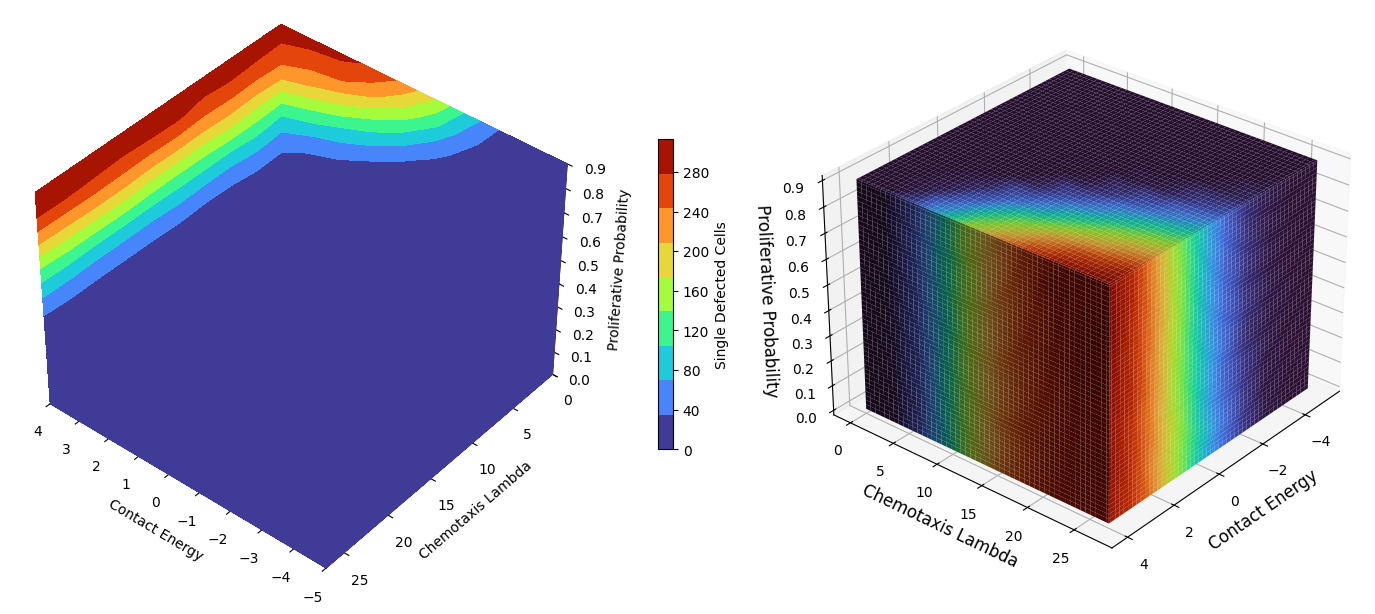

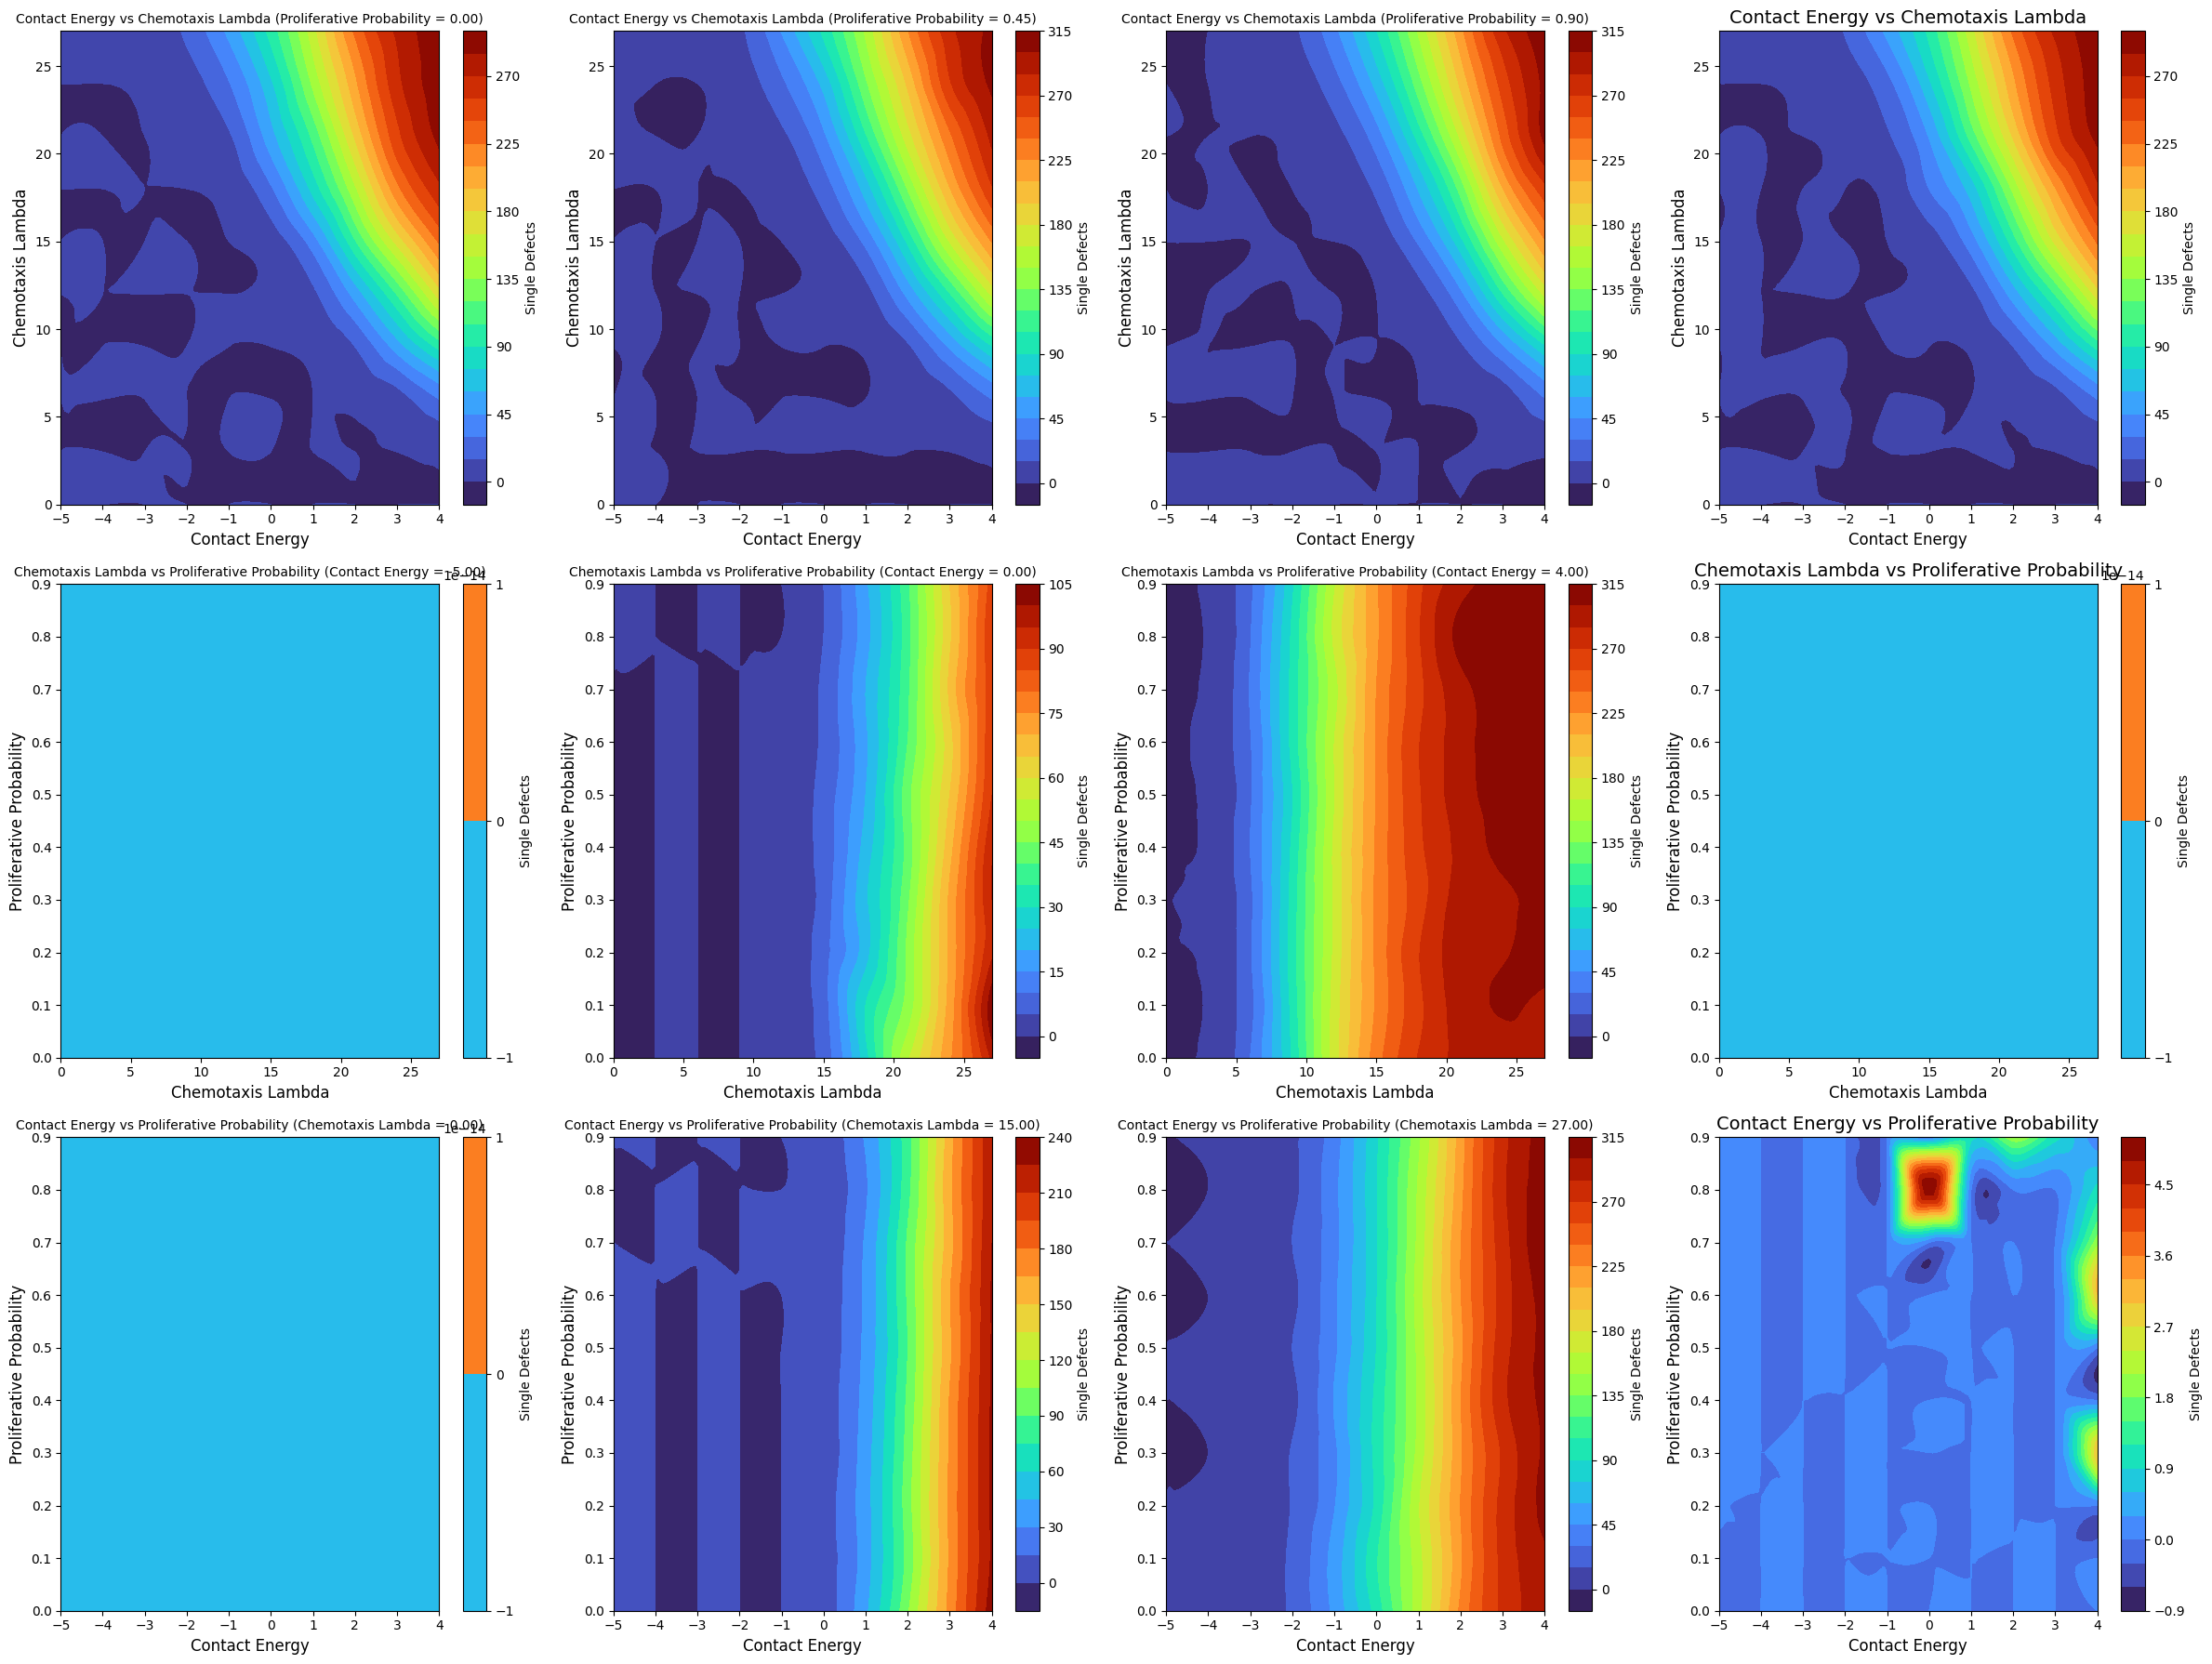

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

# Load the dataset
file_path = "/Users/sheriffakeeb/Desktop/Sample_Simulation/Outputs/Single_Defects_Mean.csv" 
df = pd.read_csv(file_path)

# Extract data from the dataset
x = df["Contact Energy"].values  
y = df["Chemotaxis Lambda"].values  
z = df["Proliferative Probability"].values  
c = df["Single Defects"].values  

# Normalize the invasive area for color mapping
c_norm = (c - c.min()) / (c.max() - c.min())

# Define the cube boundaries
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

# Create meshgrid for cube faces
X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Interpolate color values across cube faces
grid_points = np.array([x, y, z]).T
grid_values = c_norm

C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())  # Max Y
C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())  # Max X
C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())  # Max Z

# Normalize colors for each face separately
C_left_norm = (C_left - c.min()) / (c.max() - c.min())
C_right_norm = (C_right - c.min()) / (c.max() - c.min())
C_top_norm = (C_top - c.min()) / (c.max() - c.min())

# Define grid size for interpolation
Nx, Ny, Nz = 10, 10, 10  # Adjusting for computational efficiency
P, Q, R = np.meshgrid(np.linspace(x.min(), x.max(), Nx),
                       np.linspace(y.min(), y.max(), Ny),
                       np.linspace(z.min(), z.max(), Nz))

# Reshape the invasive area data
c_grid = c.reshape((Nx, Ny, Nz), order='F')

# Define contour levels and limits
kw = {
    'vmin': c_grid.min(),
    'vmax': c_grid.max(),
    'levels': np.linspace(c_grid.min(), c_grid.max(), 10),
    'cmap': 'turbo'
}

# Create figure with subplots
fig = plt.figure(figsize=(16, 6))

# First subplot - Contour plot (formerly ax2, now ax1)
ax1 = fig.add_subplot(121, projection='3d')

# Plot contour surfaces
_ = ax1.contourf(
    P[:, :, 0], Q[:, :, 0], c_grid[:, :, 0],
    zdir='z', offset=z.min(), **kw
)
_ = ax1.contourf(
    P[0, :, :], c_grid[0, :, :], R[0, :, :],
    zdir='y', offset=y.min(), **kw
)
C = ax1.contourf(
    c_grid[:, -1, :], Q[:, -1, :], R[:, -1, :],
    zdir='x', offset=x.max(), **kw
)

# Set plot limits and labels
ax1.set(
    xlim=[P.min(), P.max()],
    ylim=[Q.min(), Q.max()],
    zlim=[R.min(), R.max()],
    xlabel='Contact Energy',
    ylabel='Chemotaxis Lambda',
    zlabel='Proliferative Probability',
)

# Set view angle
ax1.view_init(40, 130)

# Second subplot - Cube with interpolated faces (formerly ax1, now ax2)
ax2 = fig.add_subplot(122, projection='3d')

# Define colormap normalization
norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())
colormap = cm.turbo

# Plot cube faces with color mapping
ax2.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(C_left_norm), edgecolor='none', alpha=1.0)  # Max Y face
ax2.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(C_right_norm), edgecolor='none', alpha=1.0)  # Max X face
ax2.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(C_top_norm), edgecolor='none', alpha=1.0)  # Max Z face

# Set axis labels
ax2.set_xlabel("Contact Energy", fontsize=12)
ax2.set_ylabel("Chemotaxis Lambda", fontsize=12)
ax2.set_zlabel("Proliferative Probability", fontsize=12)

# Adjust viewing angle
ax2.view_init(elev=30, azim=40)

# Add colorbar to ax1 (contour plot)
cbar = fig.colorbar(C, ax=ax1, fraction=0.02, pad=0.1, label='Single Defected Cells')
cbar.locator = ticker.MaxNLocator(integer=True)
cbar.update_ticks()

# Show combined plots
plt.tight_layout()
plt.show()



# --------------------------------------
# Generate 2D Plots
# --------------------------------------


# Define midpoints
x_half_new = 0
y_half_new = 15
z_half = (z.max() + z.min()) / 2

# Function to plot 2D contours for fixed parameter values
def plot_fixed_param_contours(ax, fixed_param, fixed_values, param1, param2, param1_label, param2_label):
    for i, val in enumerate(fixed_values):
        mask = np.isclose(df[fixed_param], val, atol=0.1)
        subset = df[mask]
        
        if subset.empty:
            continue

        X, Y = np.meshgrid(
            np.linspace(subset[param1].min(), subset[param1].max(), 100),
            np.linspace(subset[param2].min(), subset[param2].max(), 100)
        )

        Z = griddata((subset[param1], subset[param2]), subset["Single Defects"], (X, Y), method='cubic')
        
        if np.isnan(Z).all():
            Z = griddata((subset[param1], subset[param2]), subset["Single Defects"], (X, Y), method='nearest')

        contour = ax[i].contourf(X, Y, Z, levels=20, cmap='turbo')
        ax[i].set_xlabel(param1_label, fontsize=12)
        ax[i].set_ylabel(param2_label, fontsize=12)
        ax[i].set_title(f"{param1_label} vs {param2_label} ({fixed_param} = {val:.2f})", fontsize=10)
        fig.colorbar(contour, ax=ax[i], label="Single Defects")

# Function to plot a single 2D contour plot
def plot_2D_contour(ax, param1, param2, param1_label, param2_label):
    X, Y = np.meshgrid(np.linspace(df[param1].min(), df[param1].max(), 100),
                        np.linspace(df[param2].min(), df[param2].max(), 100))
    
    Z = griddata((df[param1], df[param2]), df["Single Defects"], (X, Y), method='cubic')

    contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo')
    ax.set_xlabel(param1_label, fontsize=12)
    ax.set_ylabel(param2_label, fontsize=12)
    ax.set_title(f"{param1_label} vs {param2_label}", fontsize=14)
    fig.colorbar(contour, ax=ax, label="Single Defects")

# Create figure with subplots arranged in the desired order
fig, axes = plt.subplots(3, 4, figsize=(24, 18))

# Plot Contact Energy vs Chemotaxis Lambda for different Proliferative Probability values
plot_fixed_param_contours(axes[0, :3], "Proliferative Probability", [z.min(), z_half, z.max()], 
                          "Contact Energy", "Chemotaxis Lambda", "Contact Energy", "Chemotaxis Lambda")

# Plot 2D contour plot for Contact Energy vs Chemotaxis Lambda
plot_2D_contour(axes[0, 3], "Contact Energy", "Chemotaxis Lambda", "Contact Energy", "Chemotaxis Lambda")

# Plot Chemotaxis Lambda vs Proliferative Probability for different Contact Energy values
plot_fixed_param_contours(axes[1, :3], "Contact Energy", [x.min(), x_half_new, x.max()], 
                          "Chemotaxis Lambda", "Proliferative Probability", "Chemotaxis Lambda", "Proliferative Probability")

# Plot 2D contour plot for Chemotaxis Lambda vs Proliferative Probability
plot_2D_contour(axes[1, 3], "Chemotaxis Lambda", "Proliferative Probability", "Chemotaxis Lambda", "Proliferative Probability")

# Plot Contact Energy vs Proliferative Probability for different Chemotaxis Lambda values
plot_fixed_param_contours(axes[2, :3], "Chemotaxis Lambda", [y.min(), y_half_new, y.max()], 
                          "Contact Energy", "Proliferative Probability", "Contact Energy", "Proliferative Probability")

# Plot 2D contour plot for Contact Energy vs Proliferative Probability
plot_2D_contour(axes[2, 3], "Contact Energy", "Proliferative Probability", "Contact Energy", "Proliferative Probability")

# Adjust layout and show plots
plt.tight_layout()
plt.show()




## Number of Branches

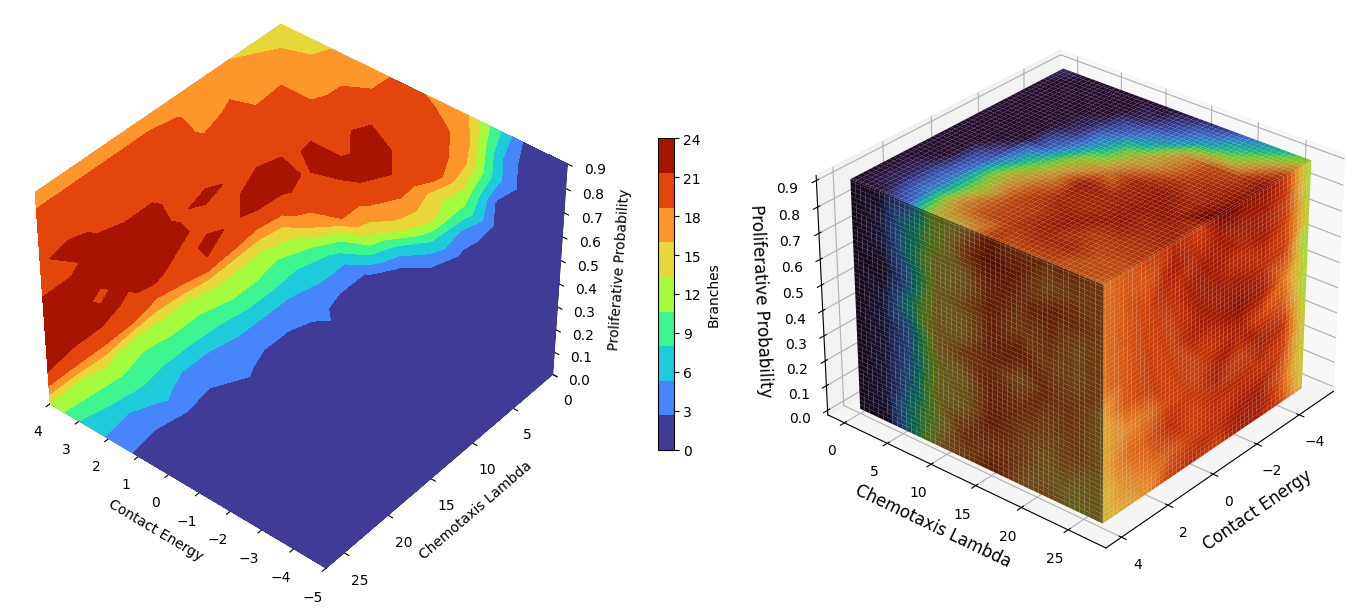

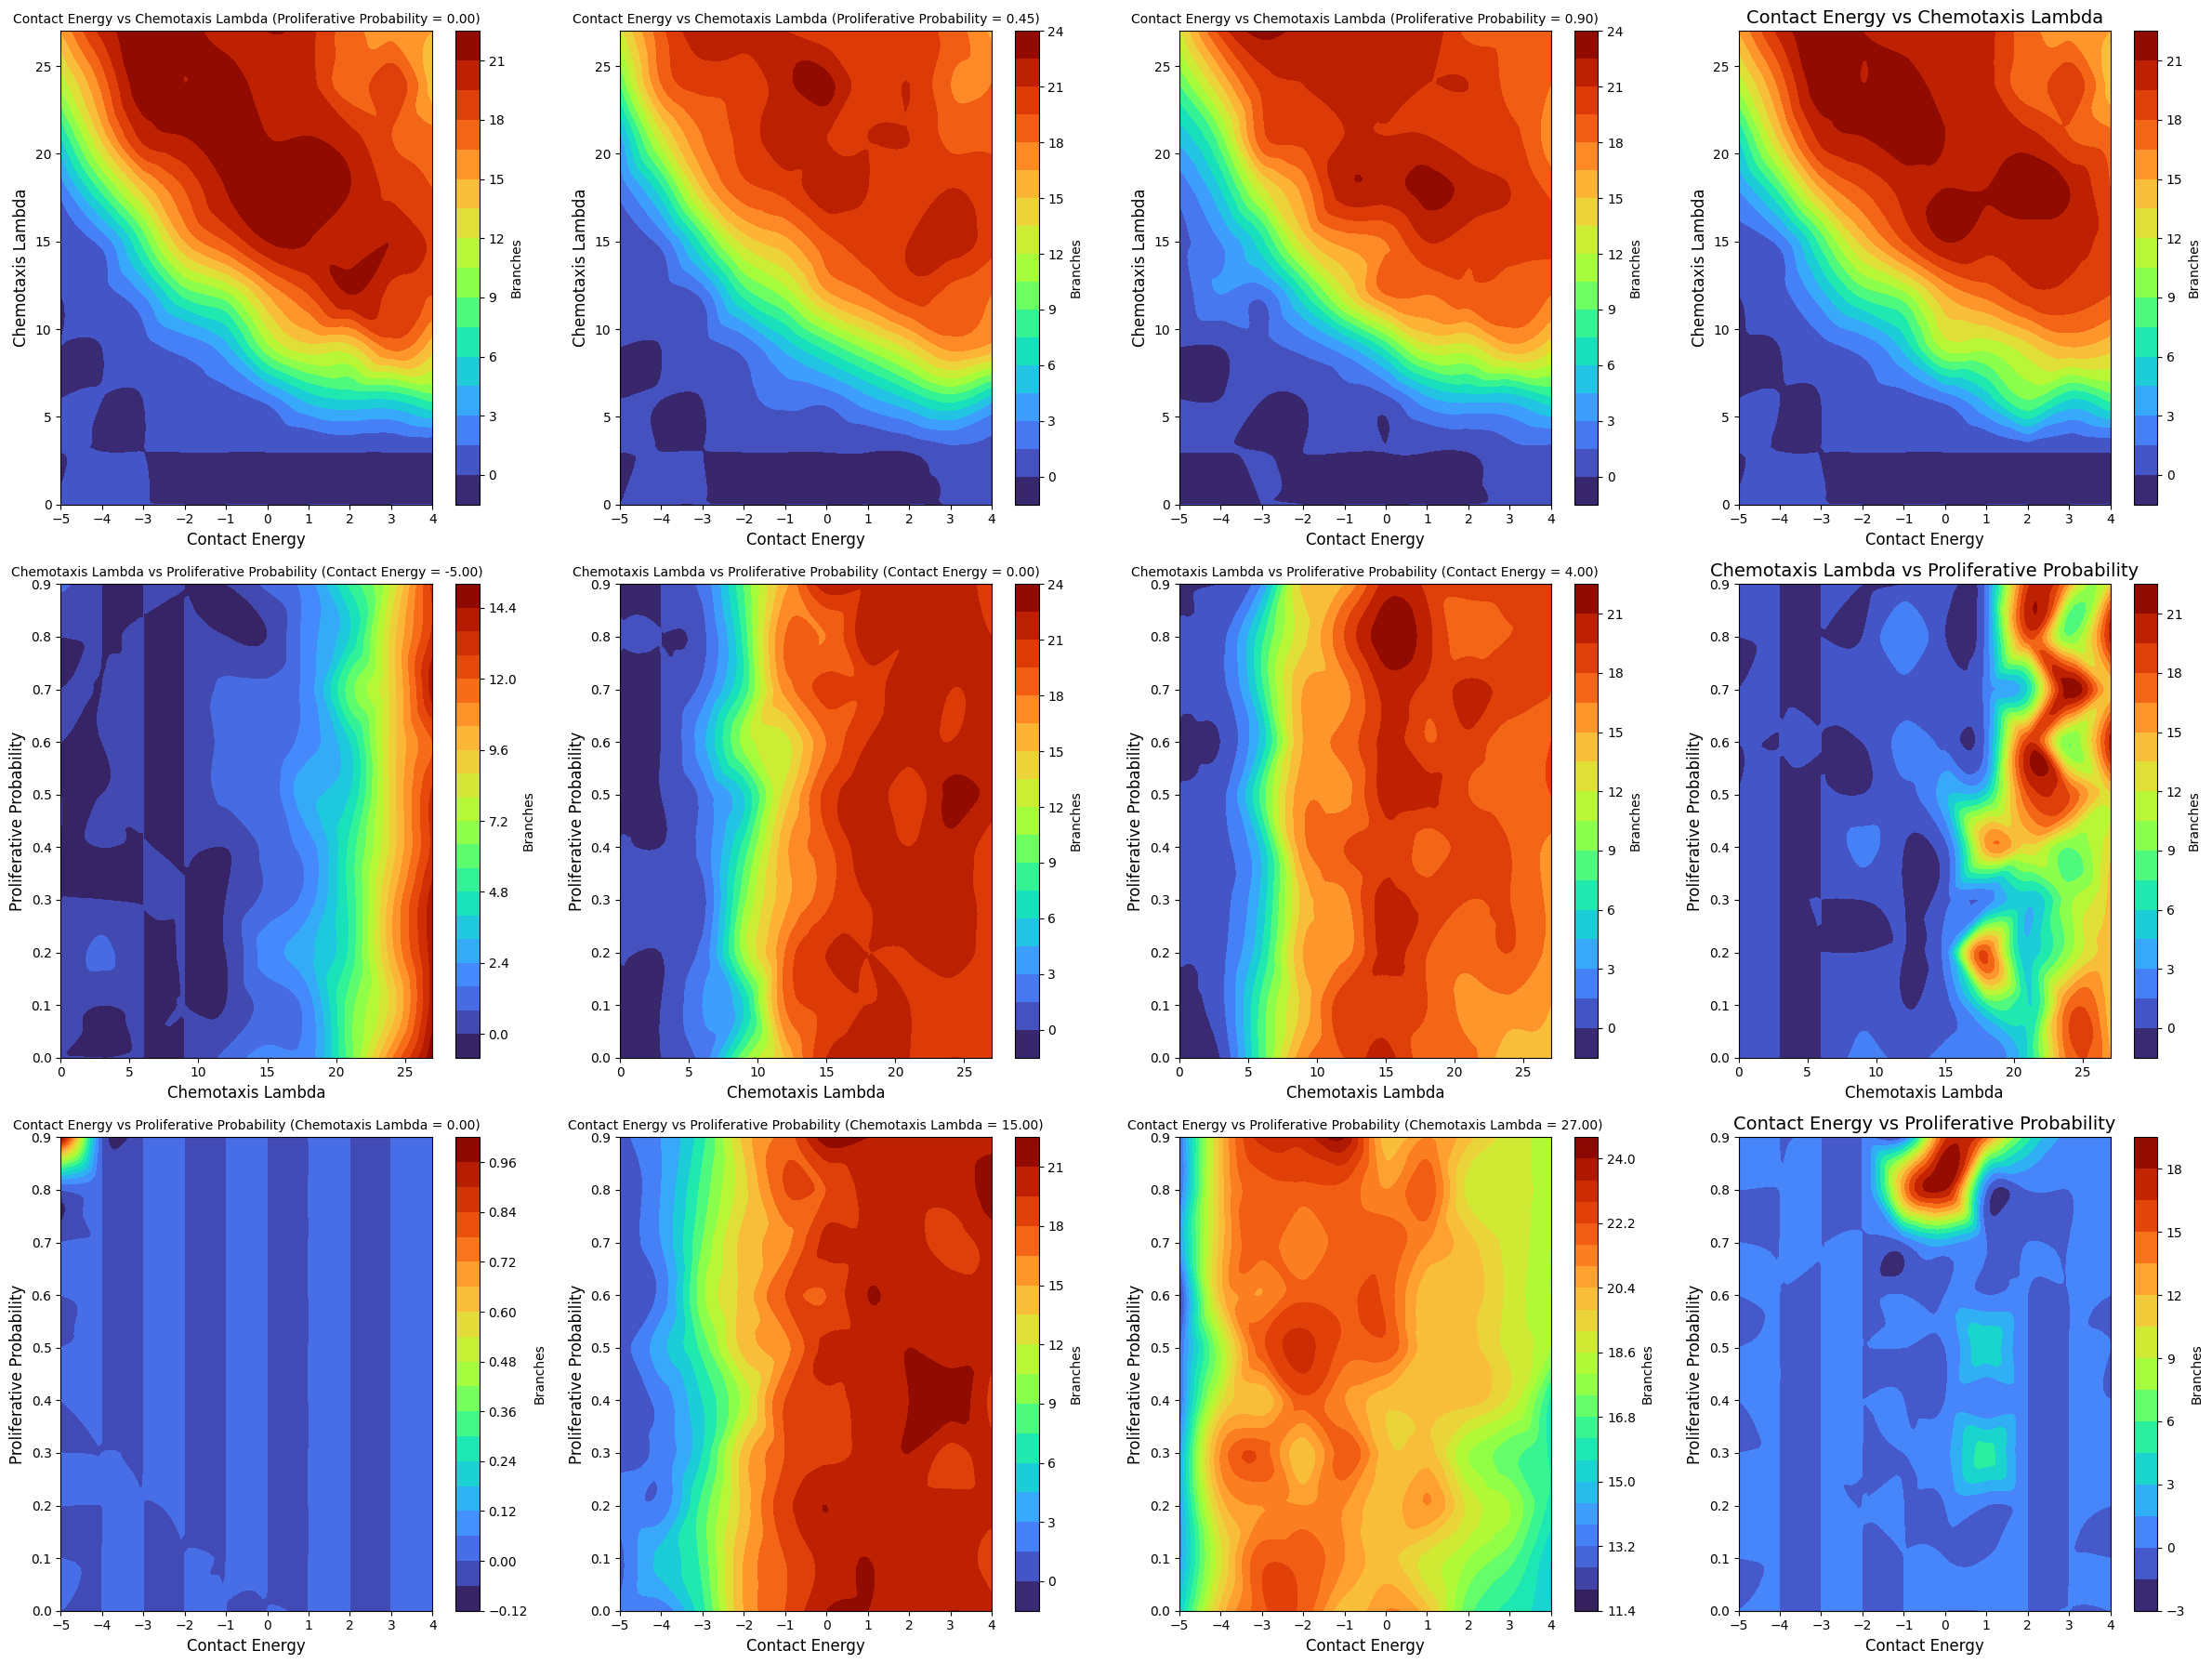

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Load the dataset
file_path = "/Users/sheriffakeeb/Desktop/Sample_Simulation/Outputs/branches_mean.csv" 
df = pd.read_csv(file_path)

# Extract data from the dataset
x = df["Contact Energy"].values  
y = df["Chemotaxis Lambda"].values  
z = df["Proliferative Probability"].values  
c = df["Branches"].values  

# Normalize the invasive area for color mapping
c_norm = (c - c.min()) / (c.max() - c.min())

# Define the cube boundaries
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

# Create meshgrid for cube faces
X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Interpolate color values across cube faces
grid_points = np.array([x, y, z]).T
grid_values = c_norm

C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())  # Max Y
C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())  # Max X
C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())  # Max Z

# Normalize colors for each face separately
C_left_norm = (C_left - c.min()) / (c.max() - c.min())
C_right_norm = (C_right - c.min()) / (c.max() - c.min())
C_top_norm = (C_top - c.min()) / (c.max() - c.min())

# Define grid size for interpolation
Nx, Ny, Nz = 10, 10, 10  # Adjusting for computational efficiency
P, Q, R = np.meshgrid(np.linspace(x.min(), x.max(), Nx),
                       np.linspace(y.min(), y.max(), Ny),
                       np.linspace(z.min(), z.max(), Nz))

# Reshape the invasive area data
c_grid = c.reshape((Nx, Ny, Nz), order='F')

# Define contour levels and limits
kw = {
    'vmin': c_grid.min(),
    'vmax': c_grid.max(),
    'levels': np.linspace(c_grid.min(), c_grid.max(), 10),
    'cmap': 'turbo',
}

# Create figure with subplots
fig = plt.figure(figsize=(16, 6))

# First subplot - Contour plot (formerly ax2, now ax1)
ax1 = fig.add_subplot(121, projection='3d')

# Plot contour surfaces
_ = ax1.contourf(
    P[:, :, 0], Q[:, :, 0], c_grid[:, :, 0],
    zdir='z', offset=z.min(), **kw
)
_ = ax1.contourf(
    P[0, :, :], c_grid[0, :, :], R[0, :, :],
    zdir='y', offset=y.min(), **kw
)
C = ax1.contourf(
    c_grid[:, -1, :], Q[:, -1, :], R[:, -1, :],
    zdir='x', offset=x.max(), **kw
)

# Set plot limits and labels
ax1.set(
    xlim=[P.min(), P.max()],
    ylim=[Q.min(), Q.max()],
    zlim=[R.min(), R.max()],
    xlabel='Contact Energy',
    ylabel='Chemotaxis Lambda',
    zlabel='Proliferative Probability',
)

# Set view angle
ax1.view_init(40, 130)

# Second subplot - Cube with interpolated faces (formerly ax1, now ax2)
ax2 = fig.add_subplot(122, projection='3d')

# Define colormap normalization
norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())
colormap = cm.turbo

# Plot cube faces with color mapping
ax2.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(C_left_norm), edgecolor='none', alpha=1.0)  # Max Y face
ax2.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(C_right_norm), edgecolor='none', alpha=1.0)  # Max X face
ax2.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(C_top_norm), edgecolor='none', alpha=1.0)  # Max Z face

# Set axis labels
ax2.set_xlabel("Contact Energy", fontsize=12)
ax2.set_ylabel("Chemotaxis Lambda", fontsize=12)
ax2.set_zlabel("Proliferative Probability", fontsize=12)

# Adjust viewing angle
ax2.view_init(elev=30, azim=40)

# Add colorbar to ax1 (contour plot)
cbar = fig.colorbar(C, ax=ax1, fraction=0.02, pad=0.1, label='Branches')
cbar.locator = ticker.MaxNLocator(integer=True)
cbar.update_ticks()
# Show combined plots
plt.tight_layout()
plt.show()



# --------------------------------------
# Generate 2D Plots
# --------------------------------------


# Define midpoints
x_half_new = 0
y_half_new = 15
z_half = (z.max() + z.min()) / 2

# Function to plot 2D contours for fixed parameter values
def plot_fixed_param_contours(ax, fixed_param, fixed_values, param1, param2, param1_label, param2_label):
    for i, val in enumerate(fixed_values):
        mask = np.isclose(df[fixed_param], val, atol=0.1)
        subset = df[mask]
        
        if subset.empty:
            continue

        X, Y = np.meshgrid(
            np.linspace(subset[param1].min(), subset[param1].max(), 100),
            np.linspace(subset[param2].min(), subset[param2].max(), 100)
        )

        Z = griddata((subset[param1], subset[param2]), subset["Branches"], (X, Y), method='cubic')
        
        if np.isnan(Z).all():
            Z = griddata((subset[param1], subset[param2]), subset["Branches"], (X, Y), method='nearest')

        contour = ax[i].contourf(X, Y, Z, levels=20, cmap='turbo')
        ax[i].set_xlabel(param1_label, fontsize=12)
        ax[i].set_ylabel(param2_label, fontsize=12)
        ax[i].set_title(f"{param1_label} vs {param2_label} ({fixed_param} = {val:.2f})", fontsize=10)
        fig.colorbar(contour, ax=ax[i], label="Branches")

# Function to plot a single 2D contour plot
def plot_2D_contour(ax, param1, param2, param1_label, param2_label):
    X, Y = np.meshgrid(np.linspace(df[param1].min(), df[param1].max(), 100),
                        np.linspace(df[param2].min(), df[param2].max(), 100))
    
    Z = griddata((df[param1], df[param2]), df["Branches"], (X, Y), method='cubic')

    contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo')
    ax.set_xlabel(param1_label, fontsize=12)
    ax.set_ylabel(param2_label, fontsize=12)
    ax.set_title(f"{param1_label} vs {param2_label}", fontsize=14)
    fig.colorbar(contour, ax=ax, label="Branches")

# Create figure with subplots arranged in the desired order
fig, axes = plt.subplots(3, 4, figsize=(24, 18))

# Plot Contact Energy vs Chemotaxis Lambda for different Proliferative Probability values
plot_fixed_param_contours(axes[0, :3], "Proliferative Probability", [z.min(), z_half, z.max()], 
                          "Contact Energy", "Chemotaxis Lambda", "Contact Energy", "Chemotaxis Lambda")

# Plot 2D contour plot for Contact Energy vs Chemotaxis Lambda
plot_2D_contour(axes[0, 3], "Contact Energy", "Chemotaxis Lambda", "Contact Energy", "Chemotaxis Lambda")

# Plot Chemotaxis Lambda vs Proliferative Probability for different Contact Energy values
plot_fixed_param_contours(axes[1, :3], "Contact Energy", [x.min(), x_half_new, x.max()], 
                          "Chemotaxis Lambda", "Proliferative Probability", "Chemotaxis Lambda", "Proliferative Probability")

# Plot 2D contour plot for Chemotaxis Lambda vs Proliferative Probability
plot_2D_contour(axes[1, 3], "Chemotaxis Lambda", "Proliferative Probability", "Chemotaxis Lambda", "Proliferative Probability")

# Plot Contact Energy vs Proliferative Probability for different Chemotaxis Lambda values
plot_fixed_param_contours(axes[2, :3], "Chemotaxis Lambda", [y.min(), y_half_new, y.max()], 
                          "Contact Energy", "Proliferative Probability", "Contact Energy", "Proliferative Probability")

# Plot 2D contour plot for Contact Energy vs Proliferative Probability
plot_2D_contour(axes[2, 3], "Contact Energy", "Proliferative Probability", "Contact Energy", "Proliferative Probability")

# Adjust layout and show plots
plt.tight_layout()
plt.show()



## Total Number of Detached Cells

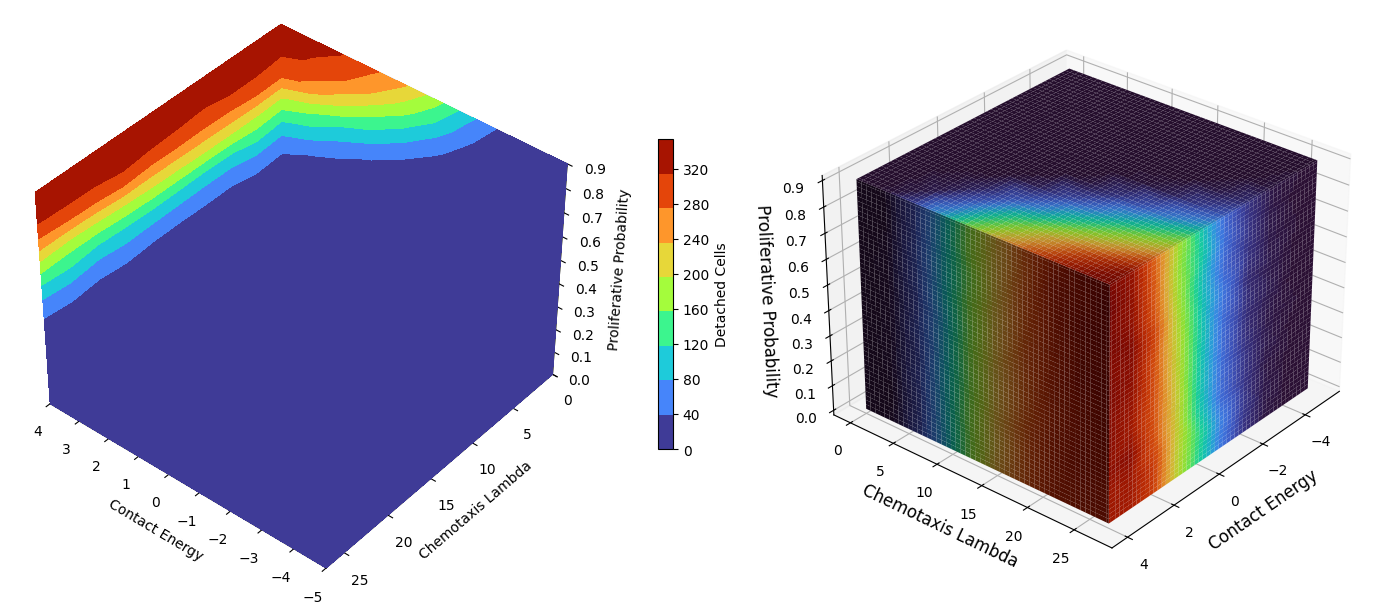

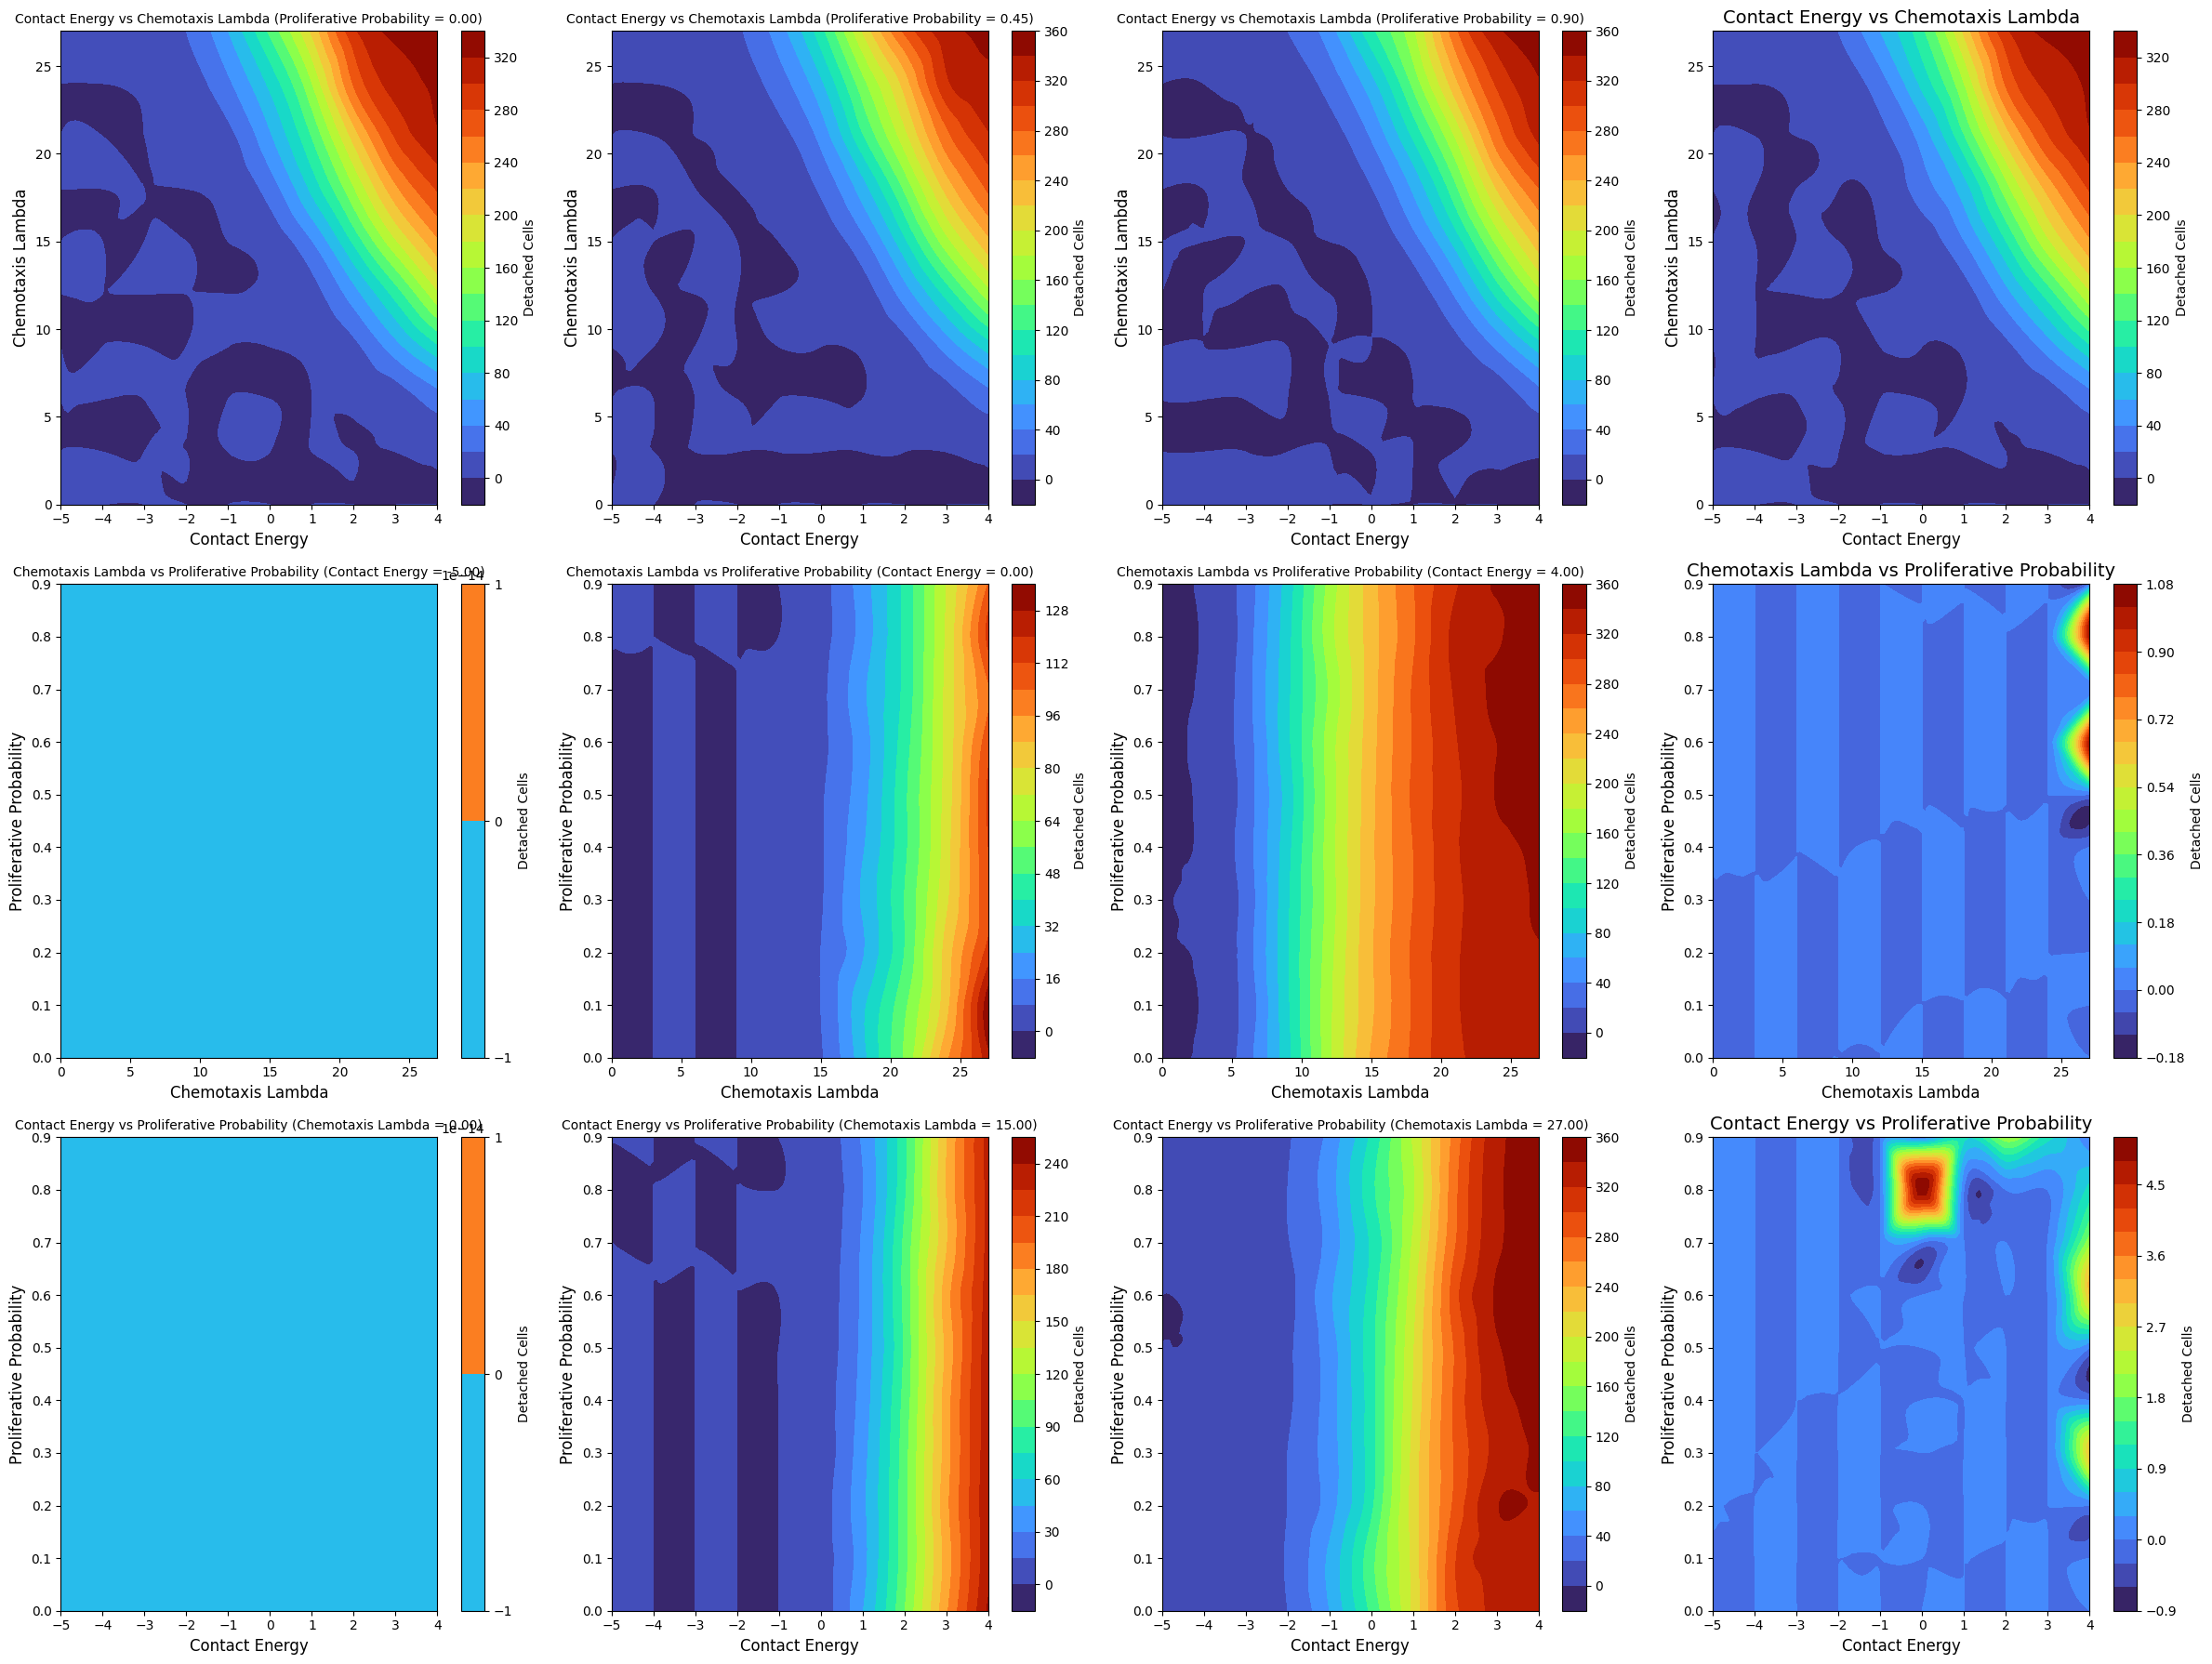

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Load the dataset
file_path = "/Users/sheriffakeeb/Desktop/Sample_Simulation/Outputs/detached_cells_mean.csv" 
df = pd.read_csv(file_path)

# Extract data from the dataset
x = df["Contact Energy"].values  
y = df["Chemotaxis Lambda"].values  
z = df["Proliferative Probability"].values  
c = df["Detached Cells"].values  

# Normalize the invasive area for color mapping
c_norm = (c - c.min()) / (c.max() - c.min())

# Define the cube boundaries
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()

# Create meshgrid for cube faces
X, Z = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(z_min, z_max, 100))
Y, _ = np.meshgrid(np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
X_top, Y_top = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Interpolate color values across cube faces
grid_points = np.array([x, y, z]).T
grid_values = c_norm

C_left = griddata(grid_points, c, (X, np.full_like(X, y_max), Z), method='linear', fill_value=c.min())  # Max Y
C_right = griddata(grid_points, c, (np.full_like(Y, x_max), Y, Z), method='linear', fill_value=c.min())  # Max X
C_top = griddata(grid_points, c, (X_top, Y_top, np.full_like(X_top, z_max)), method='linear', fill_value=c.min())  # Max Z

# Normalize colors for each face separately
C_left_norm = (C_left - c.min()) / (c.max() - c.min())
C_right_norm = (C_right - c.min()) / (c.max() - c.min())
C_top_norm = (C_top - c.min()) / (c.max() - c.min())

# Define grid size for interpolation
Nx, Ny, Nz = 10, 10, 10  # Adjusting for computational efficiency
P, Q, R = np.meshgrid(np.linspace(x.min(), x.max(), Nx),
                       np.linspace(y.min(), y.max(), Ny),
                       np.linspace(z.min(), z.max(), Nz))

# Reshape the invasive area data
c_grid = c.reshape((Nx, Ny, Nz), order='F')

# Define contour levels and limits
kw = {
    'vmin': c_grid.min(),
    'vmax': c_grid.max(),
    'levels': np.linspace(c_grid.min(), c_grid.max(), 10),
    'cmap': 'turbo',
}

# Create figure with subplots
fig = plt.figure(figsize=(16, 6))

# First subplot - Contour plot (formerly ax2, now ax1)
ax1 = fig.add_subplot(121, projection='3d')

# Plot contour surfaces
_ = ax1.contourf(
    P[:, :, 0], Q[:, :, 0], c_grid[:, :, 0],
    zdir='z', offset=z.min(), **kw
)
_ = ax1.contourf(
    P[0, :, :], c_grid[0, :, :], R[0, :, :],
    zdir='y', offset=y.min(), **kw
)
C = ax1.contourf(
    c_grid[:, -1, :], Q[:, -1, :], R[:, -1, :],
    zdir='x', offset=x.max(), **kw
)

# Set plot limits and labels
ax1.set(
    xlim=[P.min(), P.max()],
    ylim=[Q.min(), Q.max()],
    zlim=[R.min(), R.max()],
    xlabel='Contact Energy',
    ylabel='Chemotaxis Lambda',
    zlabel='Proliferative Probability',
)

# Set view angle
ax1.view_init(40, 130)

# Second subplot - Cube with interpolated faces (formerly ax1, now ax2)
ax2 = fig.add_subplot(122, projection='3d')

# Define colormap normalization
norm = mcolors.Normalize(vmin=c.min(), vmax=c.max())
colormap = cm.turbo

# Plot cube faces with color mapping
ax2.plot_surface(X, np.full_like(X, y_max), Z, facecolors=colormap(C_left_norm), edgecolor='none', alpha=1.0)  # Max Y face
ax2.plot_surface(np.full_like(Y, x_max), Y, Z, facecolors=colormap(C_right_norm), edgecolor='none', alpha=1.0)  # Max X face
ax2.plot_surface(X_top, Y_top, np.full_like(X_top, z_max), facecolors=colormap(C_top_norm), edgecolor='none', alpha=1.0)  # Max Z face

# Set axis labels
ax2.set_xlabel("Contact Energy", fontsize=12)
ax2.set_ylabel("Chemotaxis Lambda", fontsize=12)
ax2.set_zlabel("Proliferative Probability", fontsize=12)

# Adjust viewing angle
ax2.view_init(elev=30, azim=40)

# Add colorbar to ax1 (contour plot)
cbar = fig.colorbar(C, ax=ax1, fraction=0.02, pad=0.1, label='Detached Cells')
cbar.locator = ticker.MaxNLocator(integer=True)
cbar.update_ticks()
# Show combined plots
plt.tight_layout()
plt.show()



# --------------------------------------
# Generate 2D Plots
# --------------------------------------


# Define midpoints
x_half_new = 0
y_half_new = 15
z_half = (z.max() + z.min()) / 2

# Function to plot 2D contours for fixed parameter values
def plot_fixed_param_contours(ax, fixed_param, fixed_values, param1, param2, param1_label, param2_label):
    for i, val in enumerate(fixed_values):
        mask = np.isclose(df[fixed_param], val, atol=0.1)
        subset = df[mask]
        
        if subset.empty:
            continue

        X, Y = np.meshgrid(
            np.linspace(subset[param1].min(), subset[param1].max(), 100),
            np.linspace(subset[param2].min(), subset[param2].max(), 100)
        )

        Z = griddata((subset[param1], subset[param2]), subset["Detached Cells"], (X, Y), method='cubic')
        
        if np.isnan(Z).all():
            Z = griddata((subset[param1], subset[param2]), subset["Detached Cells"], (X, Y), method='nearest')

        contour = ax[i].contourf(X, Y, Z, levels=20, cmap='turbo')
        ax[i].set_xlabel(param1_label, fontsize=12)
        ax[i].set_ylabel(param2_label, fontsize=12)
        ax[i].set_title(f"{param1_label} vs {param2_label} ({fixed_param} = {val:.2f})", fontsize=10)
        fig.colorbar(contour, ax=ax[i], label="Detached Cells")

# Function to plot a single 2D contour plot
def plot_2D_contour(ax, param1, param2, param1_label, param2_label):
    X, Y = np.meshgrid(np.linspace(df[param1].min(), df[param1].max(), 100),
                        np.linspace(df[param2].min(), df[param2].max(), 100))
    
    Z = griddata((df[param1], df[param2]), df["Detached Cells"], (X, Y), method='cubic')

    contour = ax.contourf(X, Y, Z, levels=20, cmap='turbo')
    ax.set_xlabel(param1_label, fontsize=12)
    ax.set_ylabel(param2_label, fontsize=12)
    ax.set_title(f"{param1_label} vs {param2_label}", fontsize=14)
    fig.colorbar(contour, ax=ax, label="Detached Cells")

# Create figure with subplots arranged in the desired order
fig, axes = plt.subplots(3, 4, figsize=(24, 18))

# Plot Contact Energy vs Chemotaxis Lambda for different Proliferative Probability values
plot_fixed_param_contours(axes[0, :3], "Proliferative Probability", [z.min(), z_half, z.max()], 
                          "Contact Energy", "Chemotaxis Lambda", "Contact Energy", "Chemotaxis Lambda")

# Plot 2D contour plot for Contact Energy vs Chemotaxis Lambda
plot_2D_contour(axes[0, 3], "Contact Energy", "Chemotaxis Lambda", "Contact Energy", "Chemotaxis Lambda")

# Plot Chemotaxis Lambda vs Proliferative Probability for different Contact Energy values
plot_fixed_param_contours(axes[1, :3], "Contact Energy", [x.min(), x_half_new, x.max()], 
                          "Chemotaxis Lambda", "Proliferative Probability", "Chemotaxis Lambda", "Proliferative Probability")

# Plot 2D contour plot for Chemotaxis Lambda vs Proliferative Probability
plot_2D_contour(axes[1, 3], "Chemotaxis Lambda", "Proliferative Probability", "Chemotaxis Lambda", "Proliferative Probability")

# Plot Contact Energy vs Proliferative Probability for different Chemotaxis Lambda values
plot_fixed_param_contours(axes[2, :3], "Chemotaxis Lambda", [y.min(), y_half_new, y.max()], 
                          "Contact Energy", "Proliferative Probability", "Contact Energy", "Proliferative Probability")

# Plot 2D contour plot for Contact Energy vs Proliferative Probability
plot_2D_contour(axes[2, 3], "Contact Energy", "Proliferative Probability", "Contact Energy", "Proliferative Probability")

# Adjust layout and show plots
plt.tight_layout()
plt.show()

